# News & Macro Agent Prototype

This notebook runs the News & Macro Agent as an event-driven second-order investment idea generator. You can paste one news article directly, or fetch recent context for a ticker when optional packages and API keys are configured.

In [39]:
import sys
from pathlib import Path
from dotenv import load_dotenv

# Works when the notebook is launched from either the repo root or notebooks/.
CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = CURRENT_DIR if (CURRENT_DIR / "pyproject.toml").exists() else CURRENT_DIR.parent

sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / "src"))

loaded_env = load_dotenv(REPO_ROOT / ".env")
print(f"Repo root: {REPO_ROOT}")
print(f"Loaded .env: {loaded_env}")


Repo root: /Users/zhang/Github/OpenClam_Multi-Agent_Investment_Advisory
Loaded .env: True


In [40]:
import importlib
import openclam.agents.news_macro.news_macro_agent as news_macro_agent

# Reload while iterating locally so Jupyter does not keep an older dataclass definition.
news_macro_agent = importlib.reload(news_macro_agent)

analyze_news_text = news_macro_agent.analyze_news_text
collect_context = news_macro_agent.collect_context
display_report = news_macro_agent.display_report
generate_report = news_macro_agent.generate_report
save_report = news_macro_agent.save_report

mag7_q4_2025_earnings_df = news_macro_agent.mag7_q4_2025_earnings_df
build_earnings_price_eval = news_macro_agent.build_earnings_price_eval
format_return_columns = news_macro_agent.format_return_columns
plot_earnings_eval = news_macro_agent.plot_earnings_eval
run_agent_event_window_eval = news_macro_agent.run_agent_event_window_eval

print(f"Loaded news_macro_agent from: {news_macro_agent.__file__}")


Loaded news_macro_agent from: /Users/zhang/Github/OpenClam_Multi-Agent_Investment_Advisory/src/openclam/agents/news_macro/news_macro_agent.py


In [41]:
TICKER = 'NVDA'
COMPANY = 'NVIDIA'
EVENT_DATE = '2026-01-26'
LOOKBACK_DAYS = 14
NEWS_MODE =  "event_window"  # use "event_window" for historical case studies，use "latest" for newest event

## Fetch ticker context

Use this path when `yfinance` or `NEWSAPI_KEY` is configured.

In [42]:
context = collect_context(
    ticker=TICKER,
    company=COMPANY,
    event_date=EVENT_DATE,
    lookback_days=LOOKBACK_DAYS,
    max_news=10,
    news_mode=NEWS_MODE,
)

context

NewsMacroContext: NVIDIA (NVDA)
Event date: 2026-01-26 | Lookback days: 14

News items, ranked by relevance:
1. Broadcom Set To Dominate Custom AI Chip Market With 60% Share By 2027, Counterpoint Says
   Source: Benzinga / related:AVGO | Published: 2026-01-27T13:26:45Z
   Summary: Related-company context for NVDA via AVGO: Counterpoint Research says big tech companies like Alphabet (Google), Amazon, Microsoft and Apple are rapidly expanding custom AI chips to power data centers, with shipments expected to triple by 2027 as demand for faster, more effici...
   URL: https://finnhub.io/api/news?id=e961ba1b70aecf796af4be7c8ed0064433301ba1b8748465f97472bcfc2cf563
2. Here’s Why 1 Analyst Just Hiked This Monopoly’s Target to $1,642 Ahead of Earnings
   Source: Yahoo / related:ASML | Published: 2026-01-27T14:32:25Z
   Summary: Related-company context for NVDA via ASML: ASML (NASDAQ:ASML) dominates the semiconductor equipment market with its extreme ultraviolet (EUV) lithography technology, ess

In [43]:
fetched_report = generate_report(context)
display_report(fetched_report)

**📰 News Summary & Core Insight**:
In the provided window, there is no direct NVDA-specific operational update; instead, related read-through suggests continued AI data-center demand strength (custom AI chip shipments rising) and ongoing semiconductor capex/tooling momentum (ASML bookings focus), plus a competitive positioning signal that NVDA is set to surpass Apple as TSM’s top 2026 customer. Mainstream investors will likely anchor on NVDA’s demand narrative, but the second-order blind spot is that custom AI chip proliferation (AVGO read-through) can shift GPU/accelerator mix and bargaining power at the platform level, while tooling bottlenecks (ASML) and foundry customer concentration (TSM) determine how quickly incremental AI compute capacity actually converts into NVDA-addressable shipments.

**🧭 Main-Ticker Stance**:
- Short-term stance: Neutral
- Long-term stance: Bullish
- Rationale: Short-term: the macro tape (risk appetite headwinds from SPY/VIX/TNX) and the lack of direct NV

## Next integration step

Later, the CIO agent can consume `report` directly because it already contains a structured summary, core insight, investment opportunities, risk notes, citations, and raw context.

## Evaluation: Q4 2025 Earnings Window for Magnificent Seven

This section evaluates price action around the Q4 2025 earnings window, then compares short-term stance against 7-trading-day abnormal return vs QQQ and long-term stance against 63-trading-day abnormal return vs QQQ. Most evaluation logic lives in `news_macro_agent.py`; the notebook only displays results.


In [44]:
PRE_TRADING_DAYS = 7
POST_TRADING_DAYS = 7
LONG_POST_TRADING_DAYS = 63
LOOKBACK_DAYS = 14

earnings_df = mag7_q4_2025_earnings_df()
earnings_df


,ticker,company,earnings_date
0,TSLA,Tesla,2026-01-28
1,META,Meta Platforms,2026-01-28
2,AAPL,Apple,2026-01-29
3,MSFT,Microsoft,2026-01-28
4,GOOGL,Alphabet,2026-02-03
5,AMZN,Amazon,2026-02-05
6,NVDA,Nvidia,2026-02-25


In [45]:
summary_df, paths_df = build_earnings_price_eval(
    earnings_df=earnings_df,
    pre_trading_days=PRE_TRADING_DAYS,
    post_trading_days=POST_TRADING_DAYS,
    long_post_trading_days=LONG_POST_TRADING_DAYS,
    benchmarks=("SPY", "QQQ"),
)

format_return_columns(summary_df)


,ticker,company,earnings_date,pre_7d_return,post_1d_return,post_3d_return,post_7d_return,post_63d_return,full_window_return,full_63d_window_return,spy_post_7d_return,abnormal_vs_spy,spy_post_63d_return,abnormal_63d_vs_spy,qqq_post_7d_return,abnormal_vs_qqq,qqq_post_63d_return,abnormal_63d_vs_qqq,realized_direction_vs_qqq,realized_63d_direction_vs_qqq
0,TSLA,Tesla,2026-01-28,-1.75%,0.13%,-0.11%,-7.82%,-12.74%,-9.43%,-14.26%,-2.57%,-5.25%,2.61%,-15.34%,-5.40%,-2.42%,4.32%,-17.05%,down,down
1,META,Meta Platforms,2026-01-28,8.40%,-0.63%,6.47%,-0.41%,-0.16%,7.96%,8.23%,-2.57%,2.16%,2.61%,-2.77%,-5.40%,4.99%,4.32%,-4.47%,up,down
2,AAPL,Apple,2026-01-29,0.36%,0.72%,5.29%,8.45%,5.45%,8.84%,5.83%,-0.69%,9.14%,2.60%,2.85%,-3.72%,12.18%,4.61%,0.84%,up,up
3,MSFT,Microsoft,2026-01-28,5.24%,0.22%,-10.46%,-18.08%,-10.48%,-13.79%,-5.79%,-2.57%,-15.51%,2.61%,-13.09%,-5.40%,-12.68%,4.32%,-14.79%,down,down
4,GOOGL,Alphabet,2026-02-03,3.98%,-1.16%,-3.62%,-9.52%,,-5.92%,,-0.50%,-9.03%,,,-2.08%,-7.44%,,,down,None
5,AMZN,Amazon,2026-02-05,-2.28%,-4.42%,-10.42%,-14.68%,,-16.62%,,-0.65%,-14.03%,,,-0.63%,-14.05%,,,down,None
6,NVDA,Nvidia,2026-02-25,3.16%,1.41%,-8.12%,-4.93%,,-1.93%,,-0.88%,-4.05%,,,0.17%,-5.10%,,,down,None


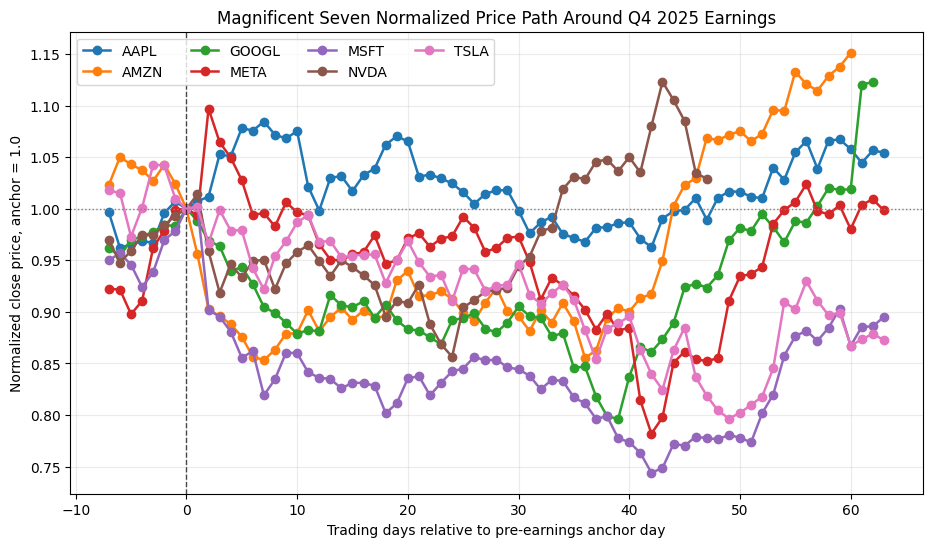

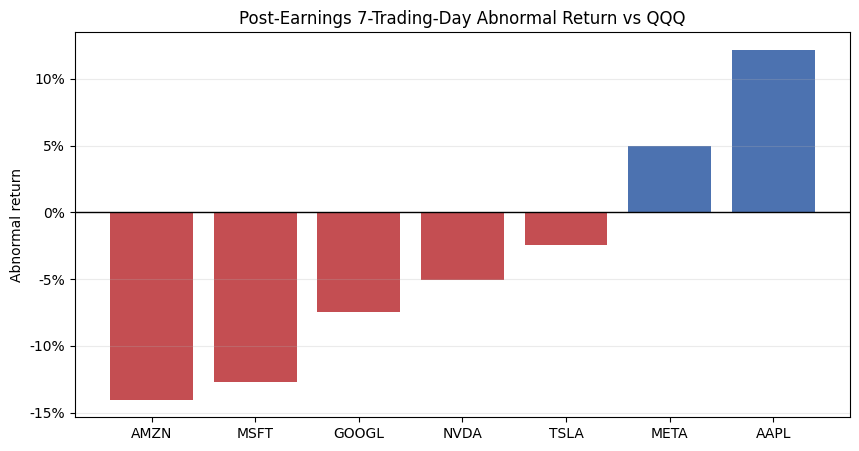

In [46]:
plot_earnings_eval(summary_df, paths_df)


In [47]:
agent_eval_hook, agent_reports = run_agent_event_window_eval(
    summary_df,
    lookback_days=LOOKBACK_DAYS,
    max_news=10,
    news_sources=["finnhub", "newsapi", "yfinance"],
    provider="auto",
    model="gpt-5.4-nano",
    gemini_model="gemini-2.5-flash",
    neutral_band=0.02,
)

agent_eval_hook


,ticker,company,earnings_date,post_7d_return,abnormal_vs_qqq,realized_direction_vs_qqq,post_63d_return,abnormal_63d_vs_qqq,realized_63d_direction_vs_qqq,news_context_ready,...,agent_short_term_stance,agent_long_term_stance,agent_stance,stance_rationale,short_direction_match,short_direction_match_reason,long_direction_match,long_direction_match_reason,direction_match,direction_match_reason
0,TSLA,Tesla,2026-01-28,-0.078185,-0.024155,down,-0.127361,-0.170536,down,True,...,Bearish,Bullish,ST: Bearish; LT: Bullish,Short-term: revenue miss despite adjusted earn...,True,matched,False,missed,True,matched
1,META,Meta Platforms,2026-01-28,-0.004101,0.049929,up,-0.001568,-0.044743,down,True,...,Bullish,Neutral,ST: Bullish; LT: Neutral,"Short-term, the strongest evidence is direct m...",True,matched,False,neutral missed: abnormal return moved outside ...,True,matched
2,AAPL,Apple,2026-01-29,0.084542,0.121764,up,0.054527,0.008438,up,True,...,Bullish,Bullish,ST: Bullish; LT: Bullish,Short-term: the strongest evidence is direct A...,True,matched,True,matched,True,matched
3,MSFT,Microsoft,2026-01-28,-0.180844,-0.126814,down,-0.104770,-0.147945,down,True,...,Bearish,Bullish,ST: Bearish; LT: Bullish,"Short term, the dominant evidence is direct MS...",True,matched,False,missed,True,matched
4,GOOGL,Alphabet,2026-02-03,-0.095231,-0.074421,down,NaN,NaN,None,True,...,Bearish,Bullish,ST: Bearish; LT: Bullish,Short-term: despite revenue acceleration (dire...,True,matched,None,missing post-earnings 7-trading-day abnormal r...,True,matched
5,AMZN,Amazon,2026-02-05,-0.146787,-0.140465,down,NaN,NaN,None,True,...,Bearish,Neutral,ST: Bearish; LT: Neutral,Short-term: direct main-ticker evidence (earni...,True,matched,None,missing post-earnings 7-trading-day abnormal r...,True,matched
6,NVDA,Nvidia,2026-02-25,-0.049313,-0.051024,down,NaN,NaN,None,True,...,Bearish,Neutral,ST: Bearish; LT: Neutral,"Short-term: despite record fundamentals, the p...",True,matched,None,missing post-earnings 7-trading-day abnormal r...,True,matched


In [48]:
format_return_columns(agent_eval_hook)


,ticker,company,earnings_date,post_7d_return,abnormal_vs_qqq,realized_direction_vs_qqq,post_63d_return,abnormal_63d_vs_qqq,realized_63d_direction_vs_qqq,news_context_ready,...,agent_short_term_stance,agent_long_term_stance,agent_stance,stance_rationale,short_direction_match,short_direction_match_reason,long_direction_match,long_direction_match_reason,direction_match,direction_match_reason
0,TSLA,Tesla,2026-01-28,-7.82%,-2.42%,down,-12.74%,-17.05%,down,True,...,Bearish,Bullish,ST: Bearish; LT: Bullish,Short-term: revenue miss despite adjusted earn...,True,matched,False,missed,True,matched
1,META,Meta Platforms,2026-01-28,-0.41%,4.99%,up,-0.16%,-4.47%,down,True,...,Bullish,Neutral,ST: Bullish; LT: Neutral,"Short-term, the strongest evidence is direct m...",True,matched,False,neutral missed: abnormal return moved outside ...,True,matched
2,AAPL,Apple,2026-01-29,8.45%,12.18%,up,5.45%,0.84%,up,True,...,Bullish,Bullish,ST: Bullish; LT: Bullish,Short-term: the strongest evidence is direct A...,True,matched,True,matched,True,matched
3,MSFT,Microsoft,2026-01-28,-18.08%,-12.68%,down,-10.48%,-14.79%,down,True,...,Bearish,Bullish,ST: Bearish; LT: Bullish,"Short term, the dominant evidence is direct MS...",True,matched,False,missed,True,matched
4,GOOGL,Alphabet,2026-02-03,-9.52%,-7.44%,down,,,None,True,...,Bearish,Bullish,ST: Bearish; LT: Bullish,Short-term: despite revenue acceleration (dire...,True,matched,None,missing post-earnings 7-trading-day abnormal r...,True,matched
5,AMZN,Amazon,2026-02-05,-14.68%,-14.05%,down,,,None,True,...,Bearish,Neutral,ST: Bearish; LT: Neutral,Short-term: direct main-ticker evidence (earni...,True,matched,None,missing post-earnings 7-trading-day abnormal r...,True,matched
6,NVDA,Nvidia,2026-02-25,-4.93%,-5.10%,down,,,None,True,...,Bearish,Neutral,ST: Bearish; LT: Neutral,"Short-term: despite record fundamentals, the p...",True,matched,None,missing post-earnings 7-trading-day abnormal r...,True,matched
